# Stability Regression

OLS: what terrain + soil features predict NDVI anomaly stability (year-to-year consistency of a plot's deviation from the vineyard mean)?

High stability = the plot is reliably above or below average — a persistent terroir signature.  
Low stability = volatile, possibly weather-driven or management-driven.

From clustering: `mean_stability` had η² = 0.119, H = 428 — the strongest cluster discriminator by far.  
This notebook identifies which individual terrain/soil drivers explain that spatial pattern.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_pickle('../data/df.pkl')

terrain_cols = [
    'slope_x', 'slope_y',
    'pro_curve_mean', 'plan_curve_mean',
    'elev_min', 'elev_max', 'elev_mean', 'elev_dev_mean',
    'aspect_mean_sin', 'aspect_mean_cos',
    'local_relief', 'total_relief_log',
]

soil_cols = [
    'sandtotal_r', 'silttotal_r', 'claytotal_r',
    'awc_r', 'cec7_r', 'om_r',
    'ph1to1h2o_r', 'ec_r',
    'profile_depth', 'max_depth',
    'frag3to10_r', 'fraggt10_r', 'dbovendry_r', 'caco3_r',
    'drain_ord', 'restrictiondepth_cm',
]

anomaly_cols = [f'ndvi_anomaly_{w}' for w in range(36, 44)]

# Per-plot health from anomaly (vintage-corrected)
health = df.groupby('plot_id')[anomaly_cols].agg(['mean', 'std'])
health.columns = ['_'.join(c) for c in health.columns]
health['mean_vigor']     = health[[c for c in health.columns if c.endswith('_mean')]].mean(axis=1)
health['mean_stability'] = health[[c for c in health.columns if c.endswith('_std')]].mean(axis=1)
health['health']         = health['mean_vigor'] - health['mean_stability']
health = health[['mean_vigor', 'mean_stability', 'health']].reset_index()

print('Health metrics shape:', health.shape)
print(health[['mean_vigor', 'mean_stability', 'health']].describe().round(4))

Health metrics shape: (3598, 4)
       mean_vigor  mean_stability     health
count   3598.0000       3598.0000  3598.0000
mean       0.0000          0.0584    -0.0584
std        0.0672          0.0300     0.0664
min       -0.2135          0.0166    -0.2735
25%       -0.0486          0.0378    -0.1068
50%       -0.0023          0.0492    -0.0517
75%        0.0463          0.0686    -0.0133
max        0.1812          0.1766     0.1137


In [3]:
feat_cols = ['plot_id'] + terrain_cols + soil_cols
plot_df = df[feat_cols].drop_duplicates().reset_index(drop=True)

# Impute: no restriction recorded → roots reach full profile
plot_df['restrictiondepth_cm'] = plot_df['restrictiondepth_cm'].fillna(plot_df['max_depth'])
# drain_ord: impute with vineyard mode
plot_df['drain_ord'] = plot_df['drain_ord'].fillna(plot_df['drain_ord'].mode()[0])

merged = plot_df.merge(health, on='plot_id').dropna()
print('Merged shape:', merged.shape, '| nulls:', merged.isnull().sum().sum())

Merged shape: (3598, 32) | nulls: 0


## OLS: terrain + soil → mean_stability

Features are standardized before OLS so coefficients are comparable effect sizes.

In [4]:
feature_list = terrain_cols + soil_cols

scaler = StandardScaler()
X_raw = merged[feature_list].values
X_scaled = scaler.fit_transform(X_raw)
X_sm = sm.add_constant(pd.DataFrame(X_scaled, columns=feature_list))

y = merged['mean_stability'].values

result = sm.OLS(y, X_sm).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.296
Model:                            OLS   Adj. R-squared:                  0.293
Method:                 Least Squares   F-statistic:                     100.4
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          2.81e-259
Time:                        23:32:16   Log-Likelihood:                 8144.1
No. Observations:                3598   AIC:                        -1.626e+04
Df Residuals:                    3582   BIC:                        -1.616e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0584    

## VIF — check for multicollinearity

In [5]:
vif_data = pd.DataFrame({
    'feature': feature_list,
    'VIF': [variance_inflation_factor(X_scaled, i) for i in range(len(feature_list))]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))

/home/simonhans/anaconda3/envs/GrapeExpectationsML/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


            feature          VIF
         fraggt10_r 38131.828085
        ph1to1h2o_r 33332.011764
               om_r 30221.982595
       local_relief 22767.494234
        claytotal_r 20152.716008
        dbovendry_r 19465.224075
              awc_r 14235.443444
           elev_min 13086.883778
      elev_dev_mean  8096.677067
             cec7_r  7603.282614
        frag3to10_r  7327.041388
          elev_mean  6634.032739
           elev_max  4663.414673
               ec_r  4019.077482
            caco3_r  3402.702740
        silttotal_r  2869.335149
        sandtotal_r  2517.333590
          max_depth  2278.542005
      profile_depth  2278.542005
   total_relief_log    19.574649
            slope_x    11.384163
    aspect_mean_cos     9.446858
            slope_y     7.777361
    aspect_mean_sin     6.292207
restrictiondepth_cm     5.887413
     pro_curve_mean     1.156492
    plan_curve_mean     1.030804
          drain_ord          NaN


## Coefficient Plot

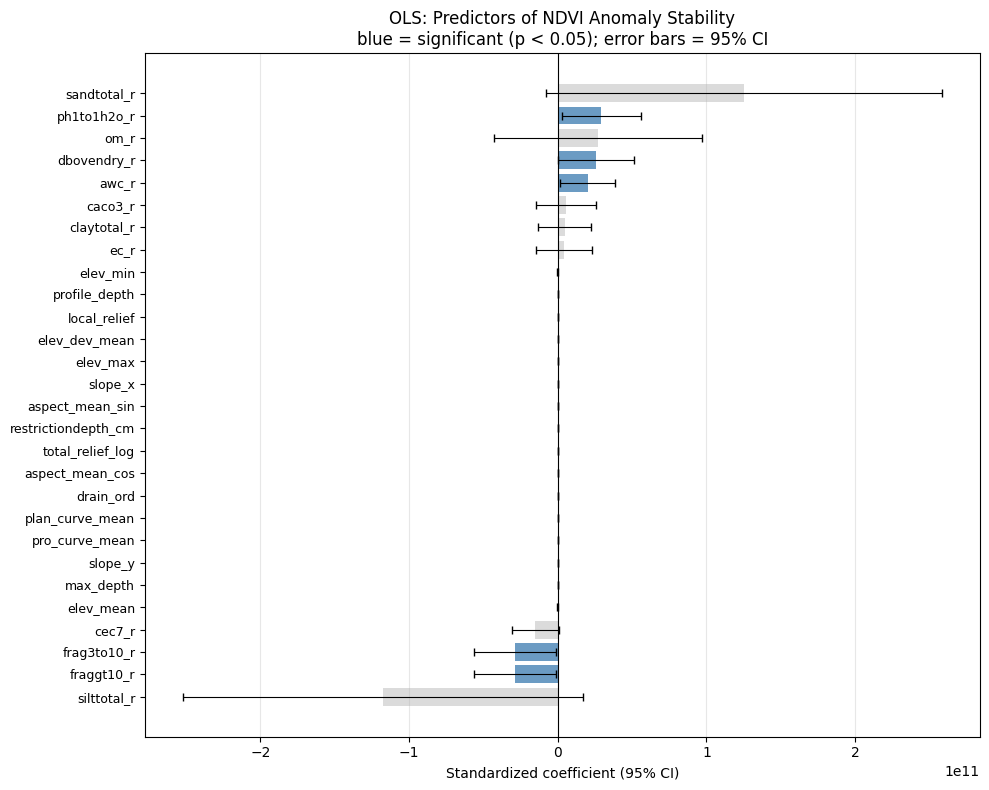

In [6]:
coef = result.params.drop('const')
ci   = result.conf_int().drop('const')
pval = result.pvalues.drop('const')

coef_df = pd.DataFrame({
    'coef':  coef,
    'lower': ci[0],
    'upper': ci[1],
    'sig':   pval < 0.05,
}).sort_values('coef')

colors = ['steelblue' if s else 'lightgray' for s in coef_df['sig']]
yerr_lower = coef_df['coef'].values - coef_df['lower'].values
yerr_upper = coef_df['upper'].values - coef_df['coef'].values

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(coef_df))

ax.barh(y_pos, coef_df['coef'], color=colors, alpha=0.8, edgecolor='none')
ax.errorbar(
    coef_df['coef'], y_pos,
    xerr=[yerr_lower, yerr_upper],
    fmt='none', color='black', capsize=3, linewidth=0.8
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_df.index, fontsize=9)
ax.set_xlabel('Standardized coefficient (95% CI)')
ax.set_title(
    'OLS: Predictors of NDVI Anomaly Stability\n'
    'blue = significant (p < 0.05); error bars = 95% CI'
)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../img/stability_coefs.png', dpi=150)
plt.show()

## Partial Regression Plots — Top 6 Significant Predictors

Shows the unique contribution of each predictor after removing the shared variance with all other features.

Top significant predictors: ['slope_x', 'elev_max', 'aspect_mean_sin', 'restrictiondepth_cm', 'ph1to1h2o_r', 'awc_r']


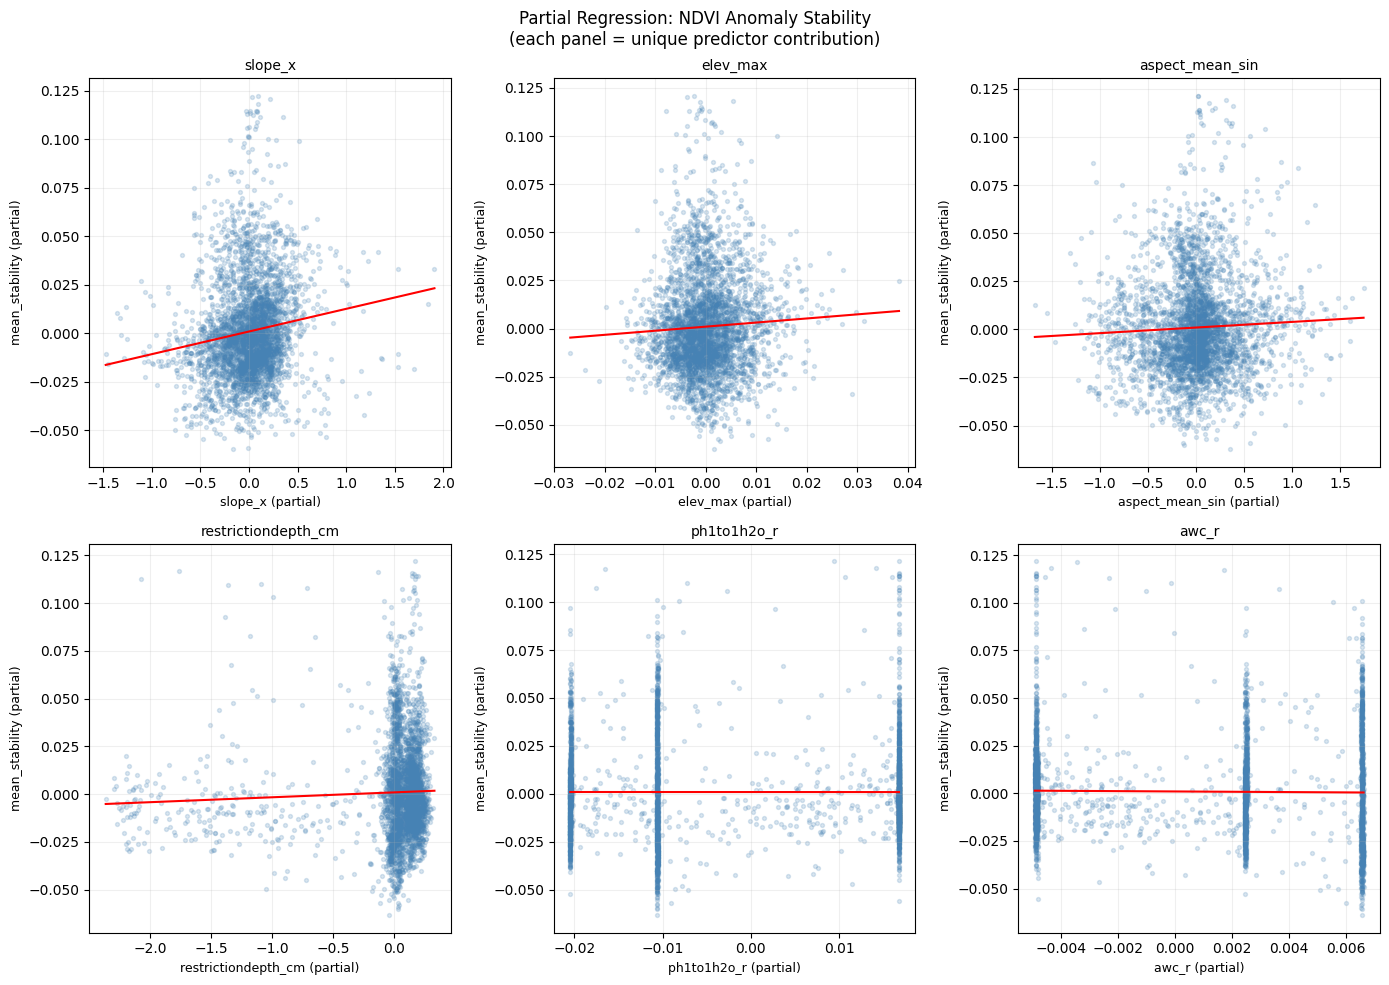

In [7]:
sig_features = pval[pval < 0.05].sort_values().index.tolist()
top_features = sig_features[:6] if len(sig_features) >= 6 else sig_features
print('Top significant predictors:', top_features)

if len(top_features) == 0:
    print('No significant predictors — skip partial regression plots')
else:
    ncols = 3
    nrows = int(np.ceil(len(top_features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
    axes_flat = axes.flat if nrows > 1 else [axes] if ncols == 1 else axes.flat

    X_df = pd.DataFrame(X_scaled, columns=feature_list)
    y_series = pd.Series(y)

    for ax, feat in zip(axes_flat, top_features):
        others = [f for f in feature_list if f != feat]
        X_others = sm.add_constant(X_df[others])

        res_y = sm.OLS(y_series, X_others).fit().resid.values
        res_x = sm.OLS(X_df[feat], X_others).fit().resid.values

        ax.scatter(res_x, res_y, alpha=0.2, s=8, color='steelblue', rasterized=True)
        m, b = np.polyfit(res_x, res_y, 1)
        xr = np.linspace(res_x.min(), res_x.max(), 200)
        ax.plot(xr, m * xr + b, color='red', linewidth=1.5)
        ax.set_xlabel(f'{feat} (partial)', fontsize=9)
        ax.set_ylabel('mean_stability (partial)', fontsize=9)
        ax.set_title(feat, fontsize=10)
        ax.grid(True, alpha=0.2)

    # Hide unused axes
    for ax in list(axes_flat)[len(top_features):]:
        ax.set_visible(False)

    plt.suptitle('Partial Regression: NDVI Anomaly Stability\n(each panel = unique predictor contribution)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../img/stability_partial_regression.png', dpi=150)
    plt.show()

## Residual Diagnostics

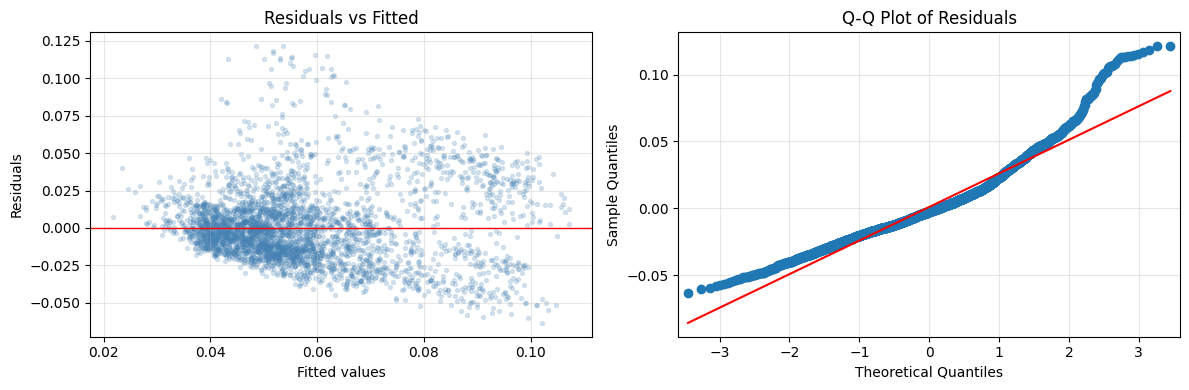

R² = 0.2960
Adj R² = 0.2931
F-stat = 100.40, p = 2.81e-259
N = 3598


In [8]:
resid = result.resid
fitted = result.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs Fitted
axes[0].scatter(fitted, resid, alpha=0.2, s=8, color='steelblue', rasterized=True)
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')
axes[0].grid(True, alpha=0.3)

# Q-Q plot
sm.qqplot(resid, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../img/stability_diagnostics.png', dpi=150)
plt.show()

print(f'R² = {result.rsquared:.4f}')
print(f'Adj R² = {result.rsquared_adj:.4f}')
print(f'F-stat = {result.fvalue:.2f}, p = {result.f_pvalue:.2e}')
print(f'N = {result.nobs:.0f}')